In [1]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'intro_to_ai/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load

# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))


Mounted at /content/drive


# GPU

You can manually switch to a GPU device on Colab by clicking `Runtime -> Change runtime type` and selecting `GPU` under `Hardware Accelerator`. You should do this before running the following cells to import packages, since the kernel gets restarted upon switching runtimes.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import numpy as np

USE_GPU = True
dtype = torch.float32 # We will be using float throughout this assignment.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cpu


##**Bonus Task: Neural Network Regression with PyTorch**

In this section, we adapt the PyTorch classification notebook to solve the Auto MPG regression task.

Using device: cpu
Dataset shape: (398, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


Train shape: (238, 7)
Validation shape: (80, 7)
Test shape: (80, 7)
Input dimension after preprocessing: 9

Running architecture candidate: (32,)
Epoch   1/40 | Train Loss: 600.8318 | Val Loss: 678.3408
Epoch   2/40 | Train Loss: 595.9841 | Val Loss: 673.2874
Epoch   3/40 | Train Loss: 591.2012 | Val Loss: 668.3595
Epoch   4/40 | Train Loss: 586.6162 | Val Loss: 663.4578
Epoch   5/40 | Train Loss: 582.0107 | Val Loss: 658.5520
Epoch   6/40 | Train Loss: 577.4551 | Val Loss: 653.4161
Epoch   7/40 | Train Loss: 572.5258 | Val Loss: 648.1262
Epoch   8/40 | Train Loss: 567.5664 | Val Loss: 642.4811
Epoch   9/40 | Train Loss: 562.1849 | Val Loss: 636.4338
Epoch  10/40 | Train Loss: 556.4373 | Val Loss: 629.9343
Epoch  11/40 | Train Loss: 550.1527 | Val Loss: 622.9836
Epoch  12/40 | Train Loss: 543.5609 | Val Loss: 615.3102
Epoch  13/40 | Train Loss: 536.3460 | Val Loss: 606.9895
Epoch  14/40 | Train Loss: 528.3975 | Val Loss: 598.1263
Epoch  15/40 | Train Loss: 519.8464 | Val Loss: 588.5325

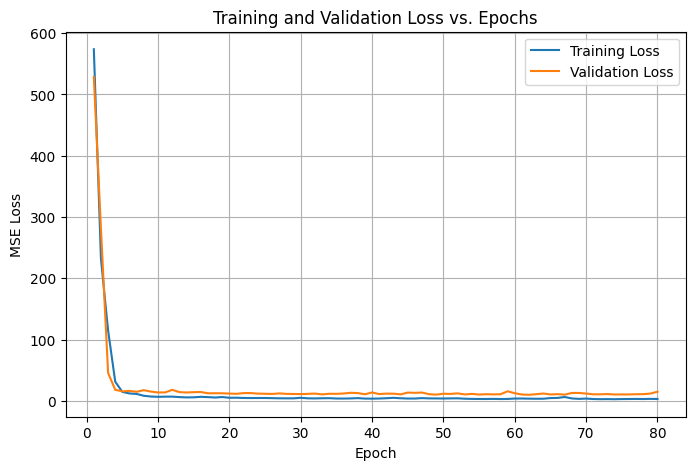

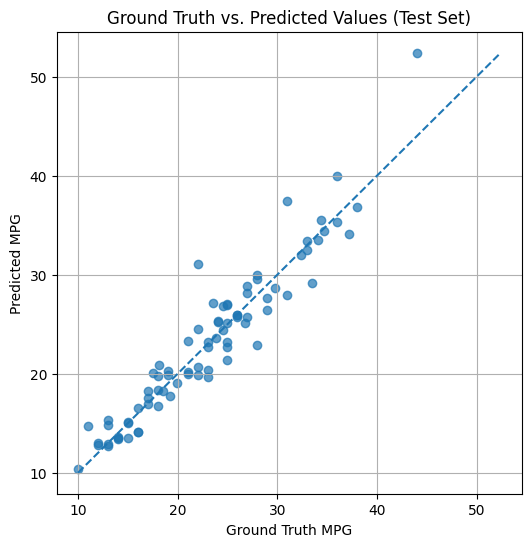

In [3]:
# ==================================================
# Bonus Task: Neural Network Regression with PyTorch
# Auto MPG
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score

# --------------------------------------------------
# settings
# --------------------------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

BATCH_SIZE = 32
SEARCH_EPOCHS = 40
FINAL_EPOCHS = 80

print("Using device:", device)

# --------------------------------------------------
# load Auto MPG dataset
# --------------------------------------------------
column_names = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin", "car_name"
]

url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

df = pd.read_csv(
    url,
    names=column_names,
    na_values="?",
    comment="\t",
    sep=r"\s+",
    skipinitialspace=True
)

# We do not use car_name in the neural network model
df = df.drop(columns=["car_name"])

print("Dataset shape:", df.shape)
display(df.head())

# --------------------------------------------------
# features / target
# --------------------------------------------------
X = df.drop(columns=["mpg"])
y = df["mpg"].astype(np.float32).values

# --------------------------------------------------
# split: train / validation / test
# 60% train, 20% validation, 20% test
# --------------------------------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# --------------------------------------------------
# preprocessing
# --------------------------------------------------
numeric_features = [
    "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year"
]
categorical_features = ["origin"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_proc = preprocess.fit_transform(X_train)
X_val_proc = preprocess.transform(X_val)
X_test_proc = preprocess.transform(X_test)

# Convert sparse matrices to dense arrays if needed
if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
    X_val_proc = X_val_proc.toarray()
    X_test_proc = X_test_proc.toarray()

X_train_proc = X_train_proc.astype(np.float32)
X_val_proc = X_val_proc.astype(np.float32)
X_test_proc = X_test_proc.astype(np.float32)

input_dim = X_train_proc.shape[1]
print("Input dimension after preprocessing:", input_dim)

# --------------------------------------------------
# custom dataset
# --------------------------------------------------
class AutoMPGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = AutoMPGDataset(X_train_proc, y_train)
val_dataset = AutoMPGDataset(X_val_proc, y_val)
test_dataset = AutoMPGDataset(X_test_proc, y_test)

loader_train = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
loader_test = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --------------------------------------------------
# helper: build model
# --------------------------------------------------
def get_activation_layer(name):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    elif name == "tanh":
        return nn.Tanh()
    elif name == "sigmoid":
        return nn.Sigmoid()
    else:
        raise ValueError(f"Unsupported activation: {name}")

def build_model(input_dim, hidden_dims, activation_name="relu", dropout_p=0.0):
    layers = []
    in_dim = input_dim

    for h in hidden_dims:
        layers.append(nn.Linear(in_dim, h))
        layers.append(get_activation_layer(activation_name))
        if dropout_p > 0:
            layers.append(nn.Dropout(dropout_p))
        in_dim = h

    # Single output for regression
    layers.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*layers)

# --------------------------------------------------
# helper: build optimizer
# --------------------------------------------------
def build_optimizer(model, optimizer_name, lr):
    if optimizer_name == "SGD":
        return optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "SGD+Momentum":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "Adam":
        return optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

# --------------------------------------------------
# helper: evaluate mean loss on a loader
# --------------------------------------------------
def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=torch.float32)
            y = y.to(device=device, dtype=torch.float32)

            preds = model(x)
            loss = criterion(preds, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

    return total_loss / total_samples

# --------------------------------------------------
# helper: collect predictions
# --------------------------------------------------
def collect_predictions(model, loader):
    model.eval()
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=torch.float32)
            preds = model(x).cpu().numpy().flatten()
            targets = y.numpy().flatten()

            all_preds.extend(preds)
            all_targets.extend(targets)

    return np.array(all_targets), np.array(all_preds)

# --------------------------------------------------
# train function
# --------------------------------------------------
def train_model(model, optimizer, criterion, loader_train, loader_val, epochs):
    train_losses = []
    val_losses = []

    model = model.to(device=device)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total_samples = 0

        for x, y in loader_train:
            x = x.to(device=device, dtype=torch.float32)
            y = y.to(device=device, dtype=torch.float32)

            optimizer.zero_grad()
            preds = model(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

            batch_size = x.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

        epoch_train_loss = running_loss / total_samples
        epoch_val_loss = evaluate_loss(model, loader_val, criterion)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f}"
        )

    return train_losses, val_losses

# --------------------------------------------------
# helper: run one candidate
# --------------------------------------------------
def run_candidate(hidden_dims, activation_name, optimizer_name, lr, dropout_p, epochs=SEARCH_EPOCHS):
    candidate_model = build_model(
        input_dim=input_dim,
        hidden_dims=hidden_dims,
        activation_name=activation_name,
        dropout_p=dropout_p
    ).to(device)

    candidate_optimizer = build_optimizer(
        candidate_model,
        optimizer_name,
        lr
    )

    criterion = nn.MSELoss()

    train_losses, val_losses = train_model(
        model=candidate_model,
        optimizer=candidate_optimizer,
        criterion=criterion,
        loader_train=loader_train,
        loader_val=loader_val,
        epochs=epochs
    )

    best_val_loss = min(val_losses)

    return {
        "model": candidate_model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss
    }

# --------------------------------------------------
# base configuration
# --------------------------------------------------
best_architecture = (64, 32)
best_activation = "relu"
best_optimizer = "Adam"
best_lr = 1e-3
best_dropout = 0.0

# ==================================================
# Stage 1: architecture
# ==================================================
architecture_candidates = [
    (32,),
    (64, 32),
    (128, 64, 32)
]

architecture_results = []

for arch in architecture_candidates:
    print("\n" + "=" * 60)
    print(f"Running architecture candidate: {arch}")

    result = run_candidate(
        hidden_dims=arch,
        activation_name=best_activation,
        optimizer_name=best_optimizer,
        lr=best_lr,
        dropout_p=best_dropout,
        epochs=SEARCH_EPOCHS
    )

    architecture_results.append({
        "candidate": str(arch),
        "validation_loss": result["best_val_loss"]
    })

architecture_df = pd.DataFrame(architecture_results).sort_values(
    by="validation_loss", ascending=True
).reset_index(drop=True)

print("\nStage 1 - Architecture comparison")
print(architecture_df.to_string(index=False))

best_architecture = eval(architecture_df.loc[0, "candidate"])
print("\nBest architecture:", best_architecture)
print("Best validation loss:", round(architecture_df.loc[0, "validation_loss"], 4))

# ==================================================
# Stage 2: activation
# ==================================================
activation_candidates = ["relu", "tanh", "sigmoid"]

activation_results = []

for act in activation_candidates:
    print("\n" + "=" * 60)
    print(f"Running activation candidate: {act}")

    result = run_candidate(
        hidden_dims=best_architecture,
        activation_name=act,
        optimizer_name=best_optimizer,
        lr=best_lr,
        dropout_p=best_dropout,
        epochs=SEARCH_EPOCHS
    )

    activation_results.append({
        "candidate": act,
        "validation_loss": result["best_val_loss"]
    })

activation_df = pd.DataFrame(activation_results).sort_values(
    by="validation_loss", ascending=True
).reset_index(drop=True)

print("\nStage 2 - Activation comparison")
print(activation_df.to_string(index=False))

best_activation = activation_df.loc[0, "candidate"]
print("\nBest activation:", best_activation)
print("Best validation loss:", round(activation_df.loc[0, "validation_loss"], 4))

# ==================================================
# Stage 3: optimizer
# ==================================================
optimizer_candidates = ["SGD", "SGD+Momentum", "Adam"]

optimizer_results = []

for opt_name in optimizer_candidates:
    print("\n" + "=" * 60)
    print(f"Running optimizer candidate: {opt_name}")

    result = run_candidate(
        hidden_dims=best_architecture,
        activation_name=best_activation,
        optimizer_name=opt_name,
        lr=best_lr,
        dropout_p=best_dropout,
        epochs=SEARCH_EPOCHS
    )

    optimizer_results.append({
        "candidate": opt_name,
        "validation_loss": result["best_val_loss"]
    })

optimizer_df = pd.DataFrame(optimizer_results).sort_values(
    by="validation_loss", ascending=True
).reset_index(drop=True)

print("\nStage 3 - Optimizer comparison")
print(optimizer_df.to_string(index=False))

best_optimizer = optimizer_df.loc[0, "candidate"]
print("\nBest optimizer:", best_optimizer)
print("Best validation loss:", round(optimizer_df.loc[0, "validation_loss"], 4))

# ==================================================
# Stage 4: learning rate
# ==================================================
lr_candidates = [1e-2, 1e-3, 5e-4]

lr_results = []

for lr in lr_candidates:
    print("\n" + "=" * 60)
    print(f"Running learning-rate candidate: {lr}")

    result = run_candidate(
        hidden_dims=best_architecture,
        activation_name=best_activation,
        optimizer_name=best_optimizer,
        lr=lr,
        dropout_p=best_dropout,
        epochs=SEARCH_EPOCHS
    )

    lr_results.append({
        "candidate": lr,
        "validation_loss": result["best_val_loss"]
    })

lr_df = pd.DataFrame(lr_results).sort_values(
    by="validation_loss", ascending=True
).reset_index(drop=True)

print("\nStage 4 - Learning rate comparison")
print(lr_df.to_string(index=False))

best_lr = lr_df.loc[0, "candidate"]
print("\nBest learning rate:", best_lr)
print("Best validation loss:", round(lr_df.loc[0, "validation_loss"], 4))

# ==================================================
# Stage 5: dropout
# ==================================================
dropout_candidates = [0.0, 0.2, 0.5]

dropout_results = []

for dp in dropout_candidates:
    print("\n" + "=" * 60)
    print(f"Running dropout candidate: {dp}")

    result = run_candidate(
        hidden_dims=best_architecture,
        activation_name=best_activation,
        optimizer_name=best_optimizer,
        lr=best_lr,
        dropout_p=dp,
        epochs=SEARCH_EPOCHS
    )

    dropout_results.append({
        "candidate": dp,
        "validation_loss": result["best_val_loss"]
    })

dropout_df = pd.DataFrame(dropout_results).sort_values(
    by="validation_loss", ascending=True
).reset_index(drop=True)

print("\nStage 5 - Dropout comparison")
print(dropout_df.to_string(index=False))

best_dropout = dropout_df.loc[0, "candidate"]
print("\nBest dropout:", best_dropout)
print("Best validation loss:", round(dropout_df.loc[0, "validation_loss"], 4))

# ==================================================
# final selected configuration
# ==================================================
print("\n" + "=" * 60)
print("Final selected configuration:")
print("Architecture:", best_architecture)
print("Activation:", best_activation)
print("Dropout:", best_dropout)
print("Optimizer:", best_optimizer)
print("Learning rate:", best_lr)

# --------------------------------------------------
# train final model on train set and monitor validation
# --------------------------------------------------
final_model = build_model(
    input_dim=input_dim,
    hidden_dims=best_architecture,
    activation_name=best_activation,
    dropout_p=best_dropout
).to(device)

final_optimizer = build_optimizer(
    final_model,
    best_optimizer,
    best_lr
)

criterion = nn.MSELoss()

final_train_losses, final_val_losses = train_model(
    model=final_model,
    optimizer=final_optimizer,
    criterion=criterion,
    loader_train=loader_train,
    loader_val=loader_val,
    epochs=FINAL_EPOCHS
)

# --------------------------------------------------
# validation metrics
# --------------------------------------------------
val_targets, val_preds = collect_predictions(final_model, loader_val)
val_mse = mean_squared_error(val_targets, val_preds)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(val_targets, val_preds)

print("\nValidation Results:")
print(f"MSE  : {val_mse:.4f}")
print(f"RMSE : {val_rmse:.4f}")
print(f"R^2  : {val_r2:.4f}")

# --------------------------------------------------
# retrain final model on train + validation
# --------------------------------------------------
X_train_full = np.vstack([X_train_proc, X_val_proc])
y_train_full = np.concatenate([y_train, y_val])

train_full_dataset = AutoMPGDataset(X_train_full, y_train_full)
loader_train_full = DataLoader(train_full_dataset, batch_size=BATCH_SIZE, shuffle=True)

final_model_full = build_model(
    input_dim=input_dim,
    hidden_dims=best_architecture,
    activation_name=best_activation,
    dropout_p=best_dropout
).to(device)

final_optimizer_full = build_optimizer(
    final_model_full,
    best_optimizer,
    best_lr
)

train_full_losses = []

for epoch in range(FINAL_EPOCHS):
    final_model_full.train()
    running_loss = 0.0
    total_samples = 0

    for x, y in loader_train_full:
        x = x.to(device=device, dtype=torch.float32)
        y = y.to(device=device, dtype=torch.float32)

        final_optimizer_full.zero_grad()
        preds = final_model_full(x)
        loss = criterion(preds, y)
        loss.backward()
        final_optimizer_full.step()

        batch_size = x.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    train_full_losses.append(epoch_loss)

    print(f"[Train+Val] Epoch {epoch + 1:3d}/{FINAL_EPOCHS} | Loss: {epoch_loss:.4f}")

# --------------------------------------------------
# final test evaluation
# --------------------------------------------------
test_targets, test_preds = collect_predictions(final_model_full, loader_test)

test_mse = mean_squared_error(test_targets, test_preds)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(test_targets, test_preds)

print("\nFinal Test Results:")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R^2  : {test_r2:.4f}")

# --------------------------------------------------
# required figure 1: training and validation loss
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, FINAL_EPOCHS + 1), final_train_losses, label="Training Loss")
plt.plot(range(1, FINAL_EPOCHS + 1), final_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss vs. Epochs")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# required figure 2: ground truth vs predicted values
# --------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(test_targets, test_preds, alpha=0.7)

min_val = min(test_targets.min(), test_preds.min())
max_val = max(test_targets.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Ground Truth MPG")
plt.ylabel("Predicted MPG")
plt.title("Ground Truth vs. Predicted Values (Test Set)")
plt.grid(True)
plt.show()